In [4]:
import numpy as np

Vg = 18.00
Fs = 50000
Ts = 1/Fs

# Measured Values From Lab 6
V0 = 9.99
a = 7/9
D = 0.384236
alpha = 0.630819
L = 1.980557814607988e-05
Ipk = 6.816
L_leakage = 0.00039e-3
Vcp = V0/a + Vg + 13.15

Wcp = (1/2)*(Ipk**2)*(L_leakage)*Vcp/(Vcp-V0)
Pcp = Wcp/Ts
Rcp = Vcp**2 / Pcp

delta = 0.1278 # 10-20% ripple
Ccp = 1/(Rcp*delta)*(Ts-Ipk*(L_leakage)/(Vcp-V0))

V_comp = (3*Ipk + 26)/20

print(f"Clamp Voltage (Vcp): {Vcp:.2f} V")
print(f"Energy Dissipated: {Wcp*1e6:.2f} uJ")
print(f"Power Dissipated: {Pcp:.2f} W")
print(f"Clamp Resistance: {Rcp:.2f} Ohms")
print(f"Clamp Capacitance: {Ccp*1e9:.2f} nF")

Clamp Voltage (Vcp): 43.99 V
Energy Dissipated: 11.72 uJ
Power Dissipated: 0.59 W
Clamp Resistance: 3302.68 Ohms
Clamp Capacitance: 47.20 nF


After adjusting my ripple and Vcp values to acceptable levels that would match a set of discrete components, I settled on a 3300$\Omega$ resistor and a 47nF capacitor for my clamp circuit.

### Data Wrangling Helper Functions

In [51]:
import pandas as pd
import csv
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.signal import find_peaks
pd.set_option('display.float_format', lambda x: '%e' % x)

def read_rigol_csv(csv_file_name):
    with open(csv_file_name) as f:
        rows = list(csv.reader(f))

    i = 0
    while rows[0][i] != "":
        i = i + 1

    numcols = i - 2
    t0 = float(rows[1][numcols])
    dT = float(rows[1][numcols+1])

    data = pd.read_csv(csv_file_name, usecols=range(0, numcols), skiprows=[1])
    data['X'] = t0 + data['X'] * dT

    return data, t0, dT

def get_channel_data(data, channel_name):
    if channel_name in data.columns:
        # return data[channel_name].rolling(10, min_periods=1, center=True).mean()
        return data[channel_name]
    return None

def analyze_oscillations(peak_matrix):
    peak_matrix = np.asarray(peak_matrix)
    if peak_matrix.ndim < 2 or len(peak_matrix) < 2:
        return 0.0, 0.0

    times = peak_matrix[:, 0]
    peaks = peak_matrix[:, 1]

    avg_period = np.mean(np.diff(times))
    fd = 1.0 / avg_period

    x1 = peaks[0]
    xnp1 = peaks[-1]
    num_cycles = len(peaks) - 1

    # given by (1/n)*ln|x1/x_(n+1)|
    delta = np.log(x1 / xnp1) / num_cycles

    zeta = delta / np.sqrt(4 * np.pi**2 + delta**2)

    return fd, zeta

def analyze_rigol_data(data, has_ch1, has_ch2, x1, x2, drainx):
    slope, ch2_mean, peak_vsh, max_vdrain = None, None, None, None
    
    if x1 is not None and x2 is not None:
        subset = data[(data['X'] >= x1) & (data['X'] <= x2)]
        
        if has_ch1 and not subset.empty:
            result = linregress(subset['X'], subset['CH1'])
            slope = result.slope
            peak_vsh = data.iloc[(data['X'] - x2).abs().argsort()[:1]]['CH1'].values

        if has_ch2:
            ch2_mean = subset['CH2'].mean()
            max_vdrain = data.iloc[(data['X'] - drainx).abs().argsort()[:1]]['CH2'].item()
            
    return slope, ch2_mean, peak_vsh, max_vdrain

### Plotting Helper Functions

In [2]:
def plot_1ch_peaks(filepath, title, channel='CH1', chlabel="Vdrain (V)", x1=None, x2=None):
    """
    Reads Rigol CSV data, applies a rolling average filter, and plots peaks within a specified range.

    Parameters
    ----------
    filepath : str
        The name of the CSV file (without extension) located in the 'data/' directory.
    title : str
        The title to display at the top of the plot.
    ch1label : str, optional
        Label for the Y-axis and the data series, by default "Shunt Voltage (Vsh)".
    x1 : float, optional
        The start time (X-axis) for peak detection. If None, no peaks are calculated.
    x2 : float, optional
        The end time (X-axis) for peak detection. If None, no peaks are calculated.

    Returns
    -------
    numpy.ndarray
        An Nx2 matrix where the first column contains peak timestamps and the 
        second column contains the corresponding peak values. Returns an empty 
        array if no peaks are found or if x1/x2 are not provided.
    """
    data, t0, dT = read_rigol_csv("data/"+filepath+".csv")
    fig, ax = plt.subplots(figsize=(10, 6))
    data[channel] = data[channel].rolling(10, min_periods=1, center=True).mean()
    data.plot(x="X", y=channel, ax=ax, label=chlabel, legend=False, color='tab:blue')

    peak_matrix = np.array([])
    if x1 is not None and x2 is not None:
        subset = data[(data['X'] >= x1) & (data['X'] <= x2)]
        indices, _ = find_peaks(subset[channel], height=0, distance=10, prominence=0.1)
        
        peak_times = subset['X'].iloc[indices].values
        peak_values = subset[channel].iloc[indices].values
        peak_matrix = np.column_stack((peak_times, peak_values))
        
        ax.plot(peak_times, peak_values, ".", color="red", label='Peaks')

    ax.set_xlabel("Time (s)", fontsize=12)
    ax.set_ylabel(chlabel, fontsize=12)
    
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return peak_matrix

def plot_rigol(filepath, title, ch1label="Shunt Voltage (Vsh)", ch2label="Drain Voltage (Vd)", x1=None, x2=None, duty_points=None, drainx=0.5e-5): 
    data, t0, dT = read_rigol_csv("data/"+filepath+".csv")
    
    ch1_smoothed = get_channel_data(data, 'CH1')
    ch2_smoothed = get_channel_data(data, 'CH2')
    
    if ch1_smoothed is not None: data['CH1'] = ch1_smoothed
    if ch2_smoothed is not None: data['CH2'] = ch2_smoothed

    slope, ch2_mean, peak_vsh, max_vdrain = analyze_rigol_data(data, ch1_smoothed is not None, ch2_smoothed is not None, x1, x2, drainx)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax2 = None

    if ch1_smoothed is not None:
        ax.plot(data['X'], data['CH1'], label=ch1label, color='tab:blue')
        ax.set_ylabel(ch1label, fontsize=12, color='tab:blue')
        if x1 is not None and x2 is not None:
            subset = data[(data['X'] >= x1) & (data['X'] <= x2)]
            fit = slope * subset['X'] + (peak_vsh - slope * x2) 
            ax.plot(subset['X'], fit, color="red", lw=3, ls=":", label='Linear Fit')
            ax.plot(x2, peak_vsh, 'r*', markersize=8, label='Vsh Peak')

    if ch2_smoothed is not None:
        plot_ax = ax if ch1_smoothed is None else ax.twinx()
        if ch1_smoothed is not None: ax2 = plot_ax
        
        plot_ax.plot(data['X'], data['CH2'], label=ch2label, color='tab:orange')
        plot_ax.set_ylabel(ch2label, fontsize=12, color='tab:orange')

        if duty_points is not None:
            for px in duty_points:
                py = data.iloc[(data['X'] - px).abs().argsort()[:1]]['CH2'].item()
                plot_ax.plot(px, py, 'go', markersize=6)

    handles, labels = ax.get_legend_handles_labels()
    if ax2:
        h2, l2 = ax2.get_legend_handles_labels()
        handles += h2
        labels += l2
        
    if len(handles) > 1:
        ax.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.02, 0.97), borderaxespad=0.)
    
    ax.set_xlabel("Time (s)", fontsize=12)
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return slope, ch2_mean, peak_vsh, max_vdrain

### Q2: Plotting Baselines
$V_{obl} = 8.99V$

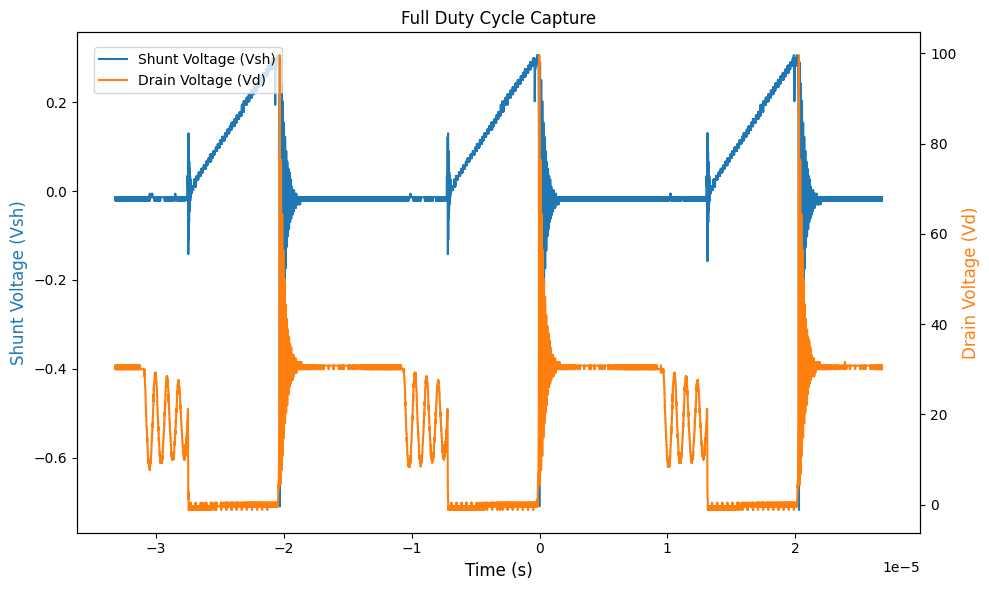

(None, None, None, None)

In [52]:
plot_rigol("8_99v_full", "Full Duty Cycle Capture")

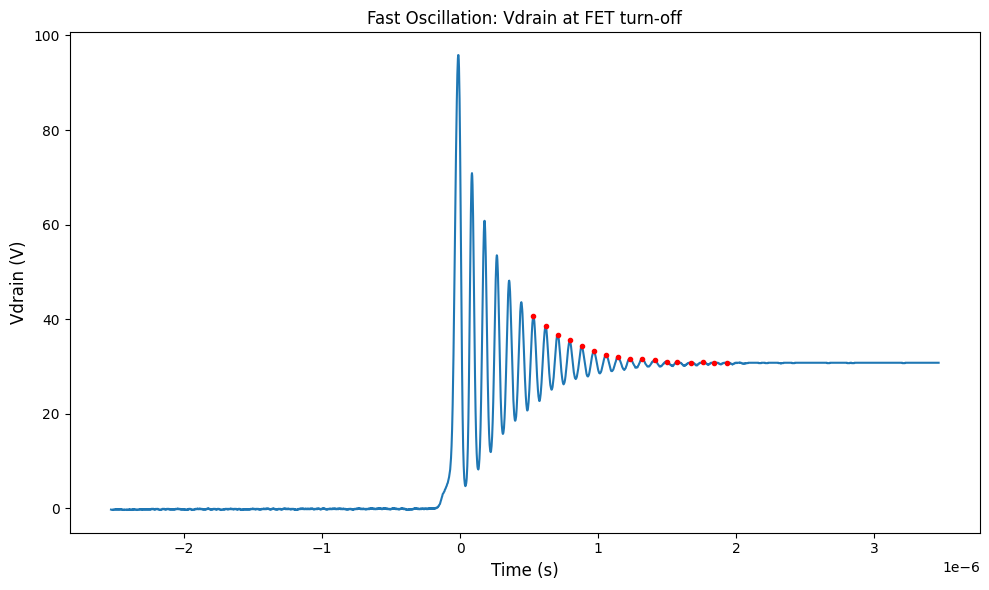

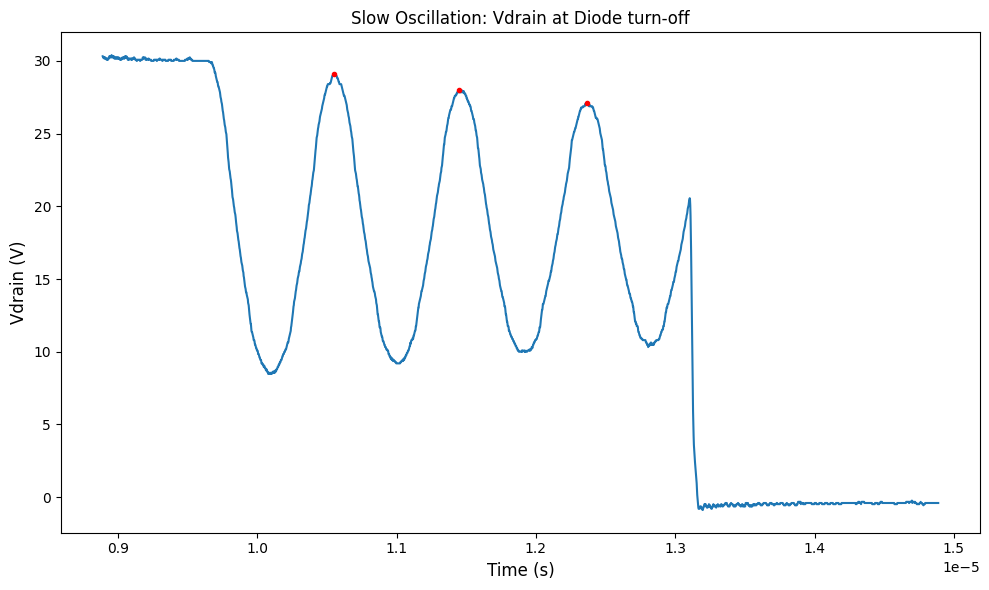

FET OFF -- Damped Natural Frequency: 11412268.19 Hz, Damping Ratio: 0.0028
DIODE OFF -- Damped Natural Frequency: 1098901.10 Hz, Damping Ratio: 0.0057


In [54]:
peaks_fetoff = plot_1ch_peaks("8_99v_f", "Fast Oscillation: Vdrain at FET turn-off", channel='CH2', x1=0.45e-6, x2=2e-6)
peaks_diodeoff = plot_1ch_peaks("8_99v_s", "Slow Oscillation: Vdrain at Diode turn-off", channel='CH2', x1=1e-5, x2=1.25e-5)

fn_fet, zeta_fet = analyze_oscillations(peaks_fetoff)
print(f"FET OFF -- Damped Natural Frequency: {fn_fet:.2f} Hz, Damping Ratio: {zeta_fet:.4f}")
fn_diode, zeta_diode = analyze_oscillations(peaks_diodeoff)
print(f"DIODE OFF -- Damped Natural Frequency: {fn_diode:.2f} Hz, Damping Ratio: {zeta_diode:.4f}")

### Q5: RCD Clamp Testing

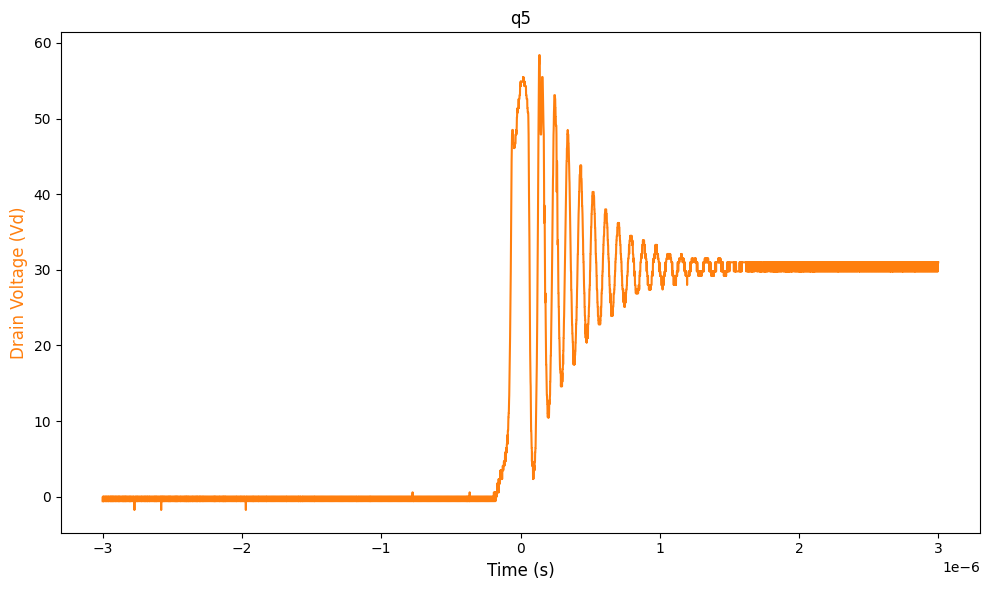

(None, None, None, None)

In [62]:
plot_rigol("8_99v_q5", "q5")

### Q7: Cathode Voltage, Shunt Current and Vd Plot

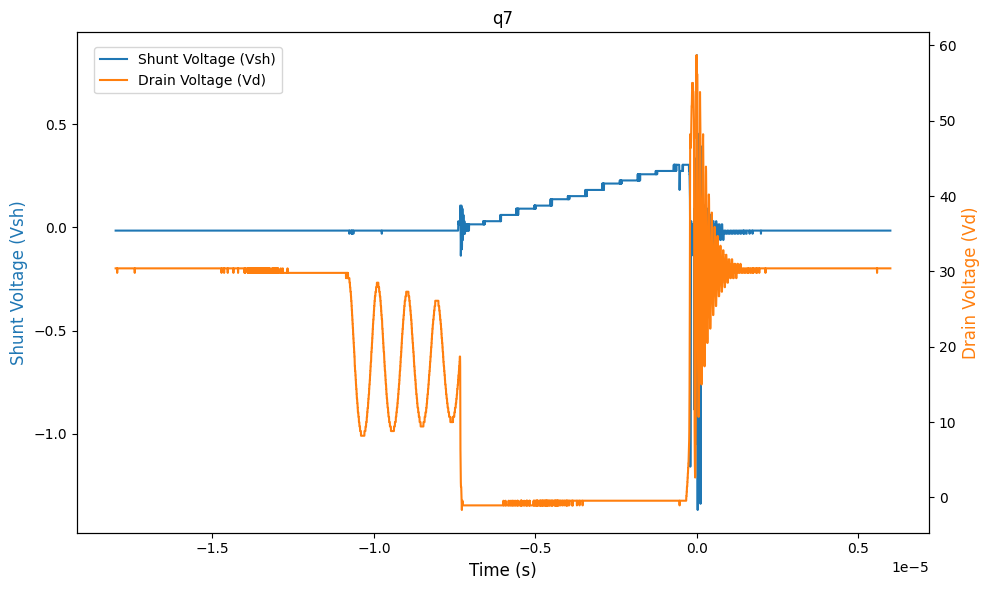

(None, None, None, None)

In [61]:
plot_rigol("8_99v_q7", "q7")

### Q8: 10V Output Cathode Voltage, Shunt Current and Vd Plot

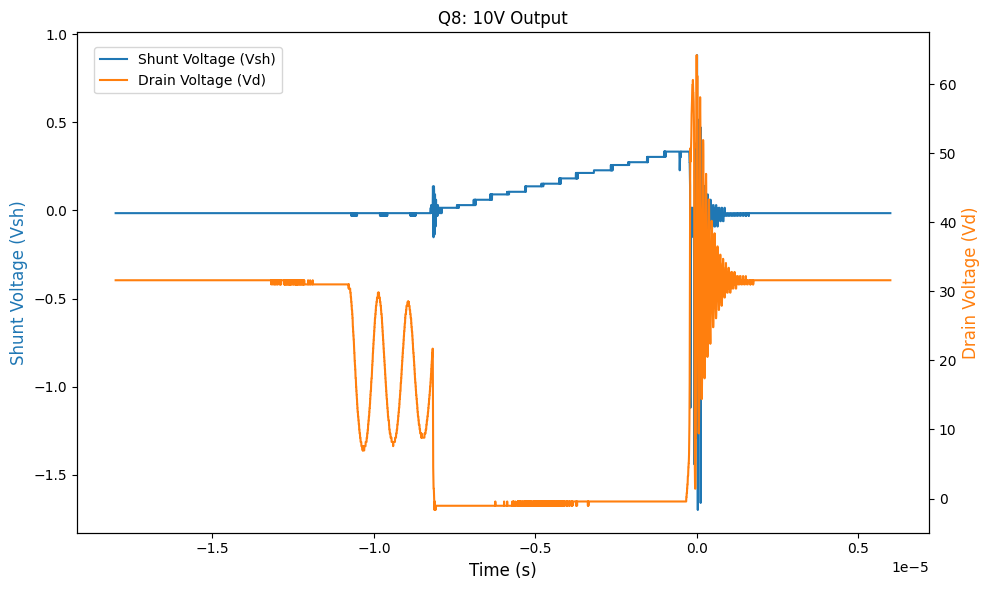

(None, None, None, None)

In [58]:
plot_rigol("10v_q8","Q8: 10V Output")

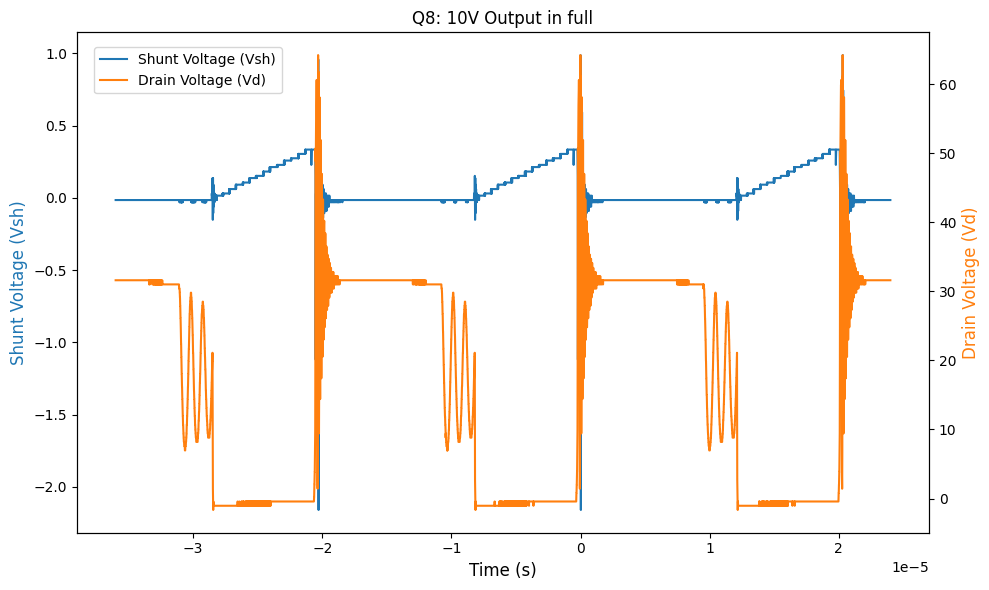

(None, None, None, None)

In [59]:
plot_rigol("10v_q8_full", "Q8: 10V Output in full")